# Issue #3 — Mob Wife Aesthetic: How Fast Did It Die?

**Pillar:** 2 (trend cycle speed)

**Story:** The mob wife aesthetic went viral on TikTok in January 2024, triggered by a video from
creator Kayla Trivieri and timed to The Sopranos' 25th anniversary. The hashtag crossed 100M+ views
within weeks. This notebook charts how fast search interest rose and fell using Google Trends, and
pairs that with a Depop resale snapshot to show who's left holding the (fur) coat.

**Scope locked:**
- Data: Google Trends, US-only, "mob wife aesthetic" (aesthetic term) + a product term (TBD, pending
  seasonality check — likely "leopard print coat" or "faux fur coat")
- Timeframe: Nov 2023–present, full window, with visual/annotation emphasis on the Nov 2023–Dec 2024 crash
- Cost beat: Depop resale price snapshot (hard data) + general fast-fashion waste stats (context only,
  not trend-specific — do not present as evidence about mob-wife purchases specifically)

## 1. Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path
from datetime import datetime
from trendspy import Trends
from pytrends.request import TrendReq

ISSUE = "issue-03"
DATA_OUT = Path(f"../data/processed/issue-03")
CHART_OUT = Path(f"../content/posts/issue-03/exports")
DATA_OUT.mkdir(parents=True, exist_ok=True)
CHART_OUT.mkdir(parents=True, exist_ok=True)

## 2. Load palette

In [8]:
# load brand palette
with open("../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.facecolor"] = CREAM
plt.rcParams["figure.facecolor"] = CREAM

## 3. Data pull

In [ ]:
# pull google trends data
tr = Trends()

df = tr.interest_over_time(
    [TERM_AESTHETIC, TERM_PRODUCT],
    timeframe="2023-11-01 2026-08-07",
    geo="US"
)
trends_df = df

In [14]:
# sanity checks
trends_df.tail()

,mob wife aesthetic,leopard print coat,isPartial
time [UTC],,,
2026-07-05,0,3,False
2026-07-12,0,4,False
2026-07-19,0,1,False
2026-07-26,1,3,False
2026-08-02,1,3,True


## 4. Seasonality check

Fur/leopard coat search terms carry natural winter seasonality regardless of any trend. Before
locking the product term, plot both lines and check whether the product term shows repeated winter
bumps in years *without* the trend (e.g. winter 2024–25, 2025–26). If so, either:
- swap to a less seasonal product term, or
- note the seasonality explicitly in `sources.md` and account for it in the chart annotation.

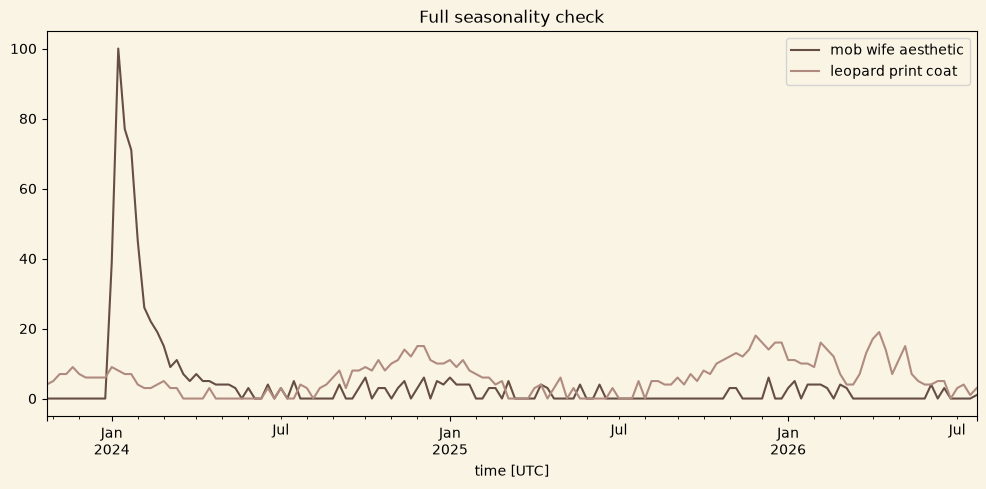

In [ ]:
trends_df_clean = trends_df[trends_df["isPartial"] == False].drop(columns=["isPartial"])

fig, ax = plt.subplots(figsize=(12, 5))
# plot trend
trends_df_clean["mob wife aesthetic"].plot(ax=ax, color=COCOA, label="mob wife aesthetic")
# plot item
trends_df_clean["leopard print coat"].plot(ax=ax, color=DUSTY, label="leopard print coat")

ax.legend()
ax.set_title("Full seasonality check")
plt.show()

## 5. Manual inputs

Figures are unable to be programatically pulled. Each one is screenshot and dated; log in `sources.md`.

In [17]:
manual_inputs = {
    "hashtag_views": {
        "value": 100_000_000,
        "label": "#mobwife hashtag views",
        "source": "Refinery29, Jan 19 2024",
        "source_url": "https://www.refinery29.com/en-us/mob-wife-aesthetic-fashion-trend-tiktok",
        "date_accessed": "2026-08-07",
    },
    "depop_resale_snapshot": {
        "items_checked": ["faux fur coat", "leopard print coat"],
        "listing_count": {"faux fur coat": 20_400, "leopard print coat": 3_780},
        "price_range_aud": {
                "faux fur coat": {"full": (15, 1500), "typical": (40, 100)},
                "leopard print coat": {"full": (20, 1000), "typical": (50, 150)},
        },
        "price_range_usd": {
            "faux fur coat": {"full": (11, 1055), "typical": (28, 70)},
            "leopard print coat": {"full": (14, 703), "typical": (35, 105)},
        },
        "conversion_rate": {"rate": 0.7030, "pair": "1 AUD = 0.7030 USD", "date": "2026-08-07"},
        "date_accessed": "2026-08-07",
        "screenshot_paths": {
            "faux fur coat": f"../../sources/screenshots/issue-03/depop_fauxfur.webp",
            "leopard print coat": f"../../sources/screenshots/issue-03/depop_leopard.webp",
        },
        "notes": "No historical Depop pricing available (platform doesn't retain past listings), so this"
                 "is a current-pricing snapshot, not a before/after collapse. Framing: these pieces are still "
                 "readily available and still affordable, right now, well after the trend's search interest "
                 "died. High-end outliers (AU$1K-1.5K) are likely vintage/designer pieces, not representative, "
                 "lead with the 'typical' range on the slide, keep 'full' range in sources.md only."
    },
    "waste_context_stat": {
        "value": "1 garbage truck of textiles landfilled or burned every second",
        "secondary_value": "$500 billion in value lost yearly to clothing that's barely worn, rarely recycled",
        "label": "Global textile waste (context only, not mob-wife-specific)",
        "source": "Ellen MacArthur Foundation, A New Textiles Economy: Redesigning Fashion's Future (2017)",
        "source_url": "https://www.ellenmacarthurfoundation.org/news/one-garbage-truck-of-textiles-wasted-every-second-report-creates-vision-for-change",
        "report_year": 2017,
        "date_accessed": "2026-08-07",
        "note": "General fast-fashion waste statistic used as CONTEXT ONLY. Do not present as "
                "trend-specific evidence. Flag the 2017 report year on the slide citation so it doesn't "
                "read as current data.",
    },
}

manual_inputs

{'hashtag_views': {'value': 100000000,
  'label': '#mobwife hashtag views',
  'source': 'Refinery29, Jan 19 2024',
  'source_url': 'https://www.refinery29.com/en-us/mob-wife-aesthetic-fashion-trend-tiktok',
  'date_accessed': '2026-08-07'},
 'depop_resale_snapshot': {'items_checked': ['faux fur coat',
   'leopard print coat'],
  'listing_count': {'faux fur coat': 20400, 'leopard print coat': 3780},
  'price_range_aud': {'faux fur coat': {'full': (15, 1500),
    'typical': (40, 100)},
   'leopard print coat': {'full': (20, 1000), 'typical': (50, 150)}},
  'price_range_usd': {'faux fur coat': {'full': (11, 1055),
    'typical': (28, 70)},
   'leopard print coat': {'full': (14, 703), 'typical': (35, 105)}},
  'conversion_rate': {'rate': 0.703,
   'pair': '1 AUD = 0.7030 USD',
   'date': '2026-08-07'},
  'date_accessed': '2026-08-07',
  'screenshot_paths': {'faux fur coat': '../../sources/screenshots/issue-03/depop_fauxfur.webp',
   'leopard print coat': '../../sources/screenshots/issue-03